# Checkpoint 01 - Machine Learning

Neste projeto, utilizamos um dataset de vendas de cafeteria para aplicar o pipeline de Machine Learning.

Foram desenvolvidos dois modelos:

- Classificação: identificar se a venda é alta ou baixa  
- Regressão: prever o valor total da venda

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("coffee_shop_sales.csv")

print(df.columns)
df.head()

Index(['transaction_id', 'timestamp', 'store_id', 'city', 'country',
       'store_type', 'product_category', 'product_name', 'unit_price',
       'quantity', 'discount_applied', 'payment_method', 'customer_id',
       'customer_age_group', 'customer_gender', 'loyalty_member',
       'weather_condition', 'temperature_c', 'holiday_name', 'total_amount'],
      dtype='object')


,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,True,Credit Card,qiyfrwsk,35-44,Female,False,Sunny,22.2,New Year's Day,2.74
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,False,Debit Card,vf0jqqnv,18-24,Male,False,Sunny,8.7,New Year's Day,4.76
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,False,Mobile Wallet,fcd6mzsg,25-34,Male,False,Sunny,8.7,New Year's Day,8.52
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,False,Credit Card,jvu2cgxu,55-64,Female,True,Cloudy,-6.5,New Year's Day,7.36
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,False,Mobile Wallet,po4ljedg,18-24,Male,True,Sunny,12.3,New Year's Day,3.42


## Preparação dos dados

Nesta etapa, realizamos a preparação dos dados para utilização nos modelos.

Criamos a variável de classificação (venda alta ou baixa), tratamos valores ausentes e transformamos as variáveis categóricas em numéricas.

In [11]:
# criando total
df["total"] = df["total_amount"]

# criando classificação
df["venda_alta"] = (df["total"] > df["total"].mean()).astype(int)

# removendo colunas inúteis
df = df.drop(["transaction_id", "customer_id", "timestamp"], axis=1, errors="ignore")

# tratando nulos
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# transformando em número
df = pd.get_dummies(df, drop_first=True)

print("nulos:", df.isnull().sum().sum())
df.head()

nulos: 0


,store_id,unit_price,quantity,discount_applied,loyalty_member,temperature_c,total_amount,total,venda_alta,city_London,...,customer_gender_Prefer not to say,weather_condition_Rainy,weather_condition_Snowy,weather_condition_Sunny,holiday_name_Boxing Day,holiday_name_Canada Day,holiday_name_Christmas Day,holiday_name_Independence Day,holiday_name_New Year's Day,holiday_name_Veterans Day
0,35,3.04,1,True,False,22.2,2.74,2.74,0,False,...,False,False,False,True,False,False,False,False,True,False
1,25,2.38,2,False,False,8.7,4.76,4.76,0,False,...,False,False,False,True,False,False,False,False,True,False
2,23,4.26,2,False,False,8.7,8.52,8.52,1,False,...,False,False,False,True,False,False,False,False,True,False
3,38,3.68,2,False,True,-6.5,7.36,7.36,1,False,...,False,False,False,False,False,False,False,False,True,False
4,9,3.42,1,False,True,12.3,3.42,3.42,0,False,...,False,False,False,True,False,False,False,False,True,False


## Modelos e divisão dos dados

Separamos os dados em treino e teste, utilizando 80% para treino e 20% para teste.

Para a classificação, utilizamos o algoritmo KNN. Já para regressão, utilizamos regressão linear.

Accuracy: 0.8815
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2712
           1       0.92      0.69      0.79      1288

    accuracy                           0.88      4000
   macro avg       0.90      0.83      0.85      4000
weighted avg       0.89      0.88      0.88      4000



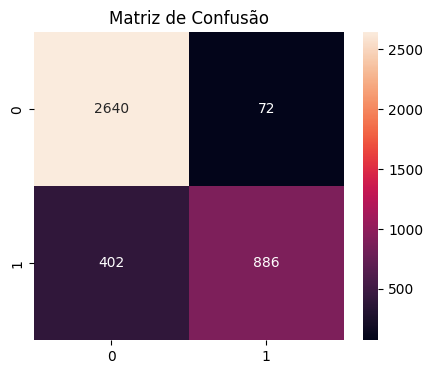

In [12]:
X = df.drop(["total", "venda_alta", "total_amount"], axis=1)

y_class = df["venda_alta"]
y_reg = df["total"]

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

# classificação
modelo_class = KNeighborsClassifier(n_neighbors=5)
modelo_class.fit(X_train, y_train)

y_pred = modelo_class.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# matriz
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusão")
plt.show()

## Regressão e avaliação

Utilizamos regressão linear para prever o valor total das vendas.

Para avaliar o modelo, utilizamos métricas como MAE, MSE, RMSE e R², além da análise do gráfico de valores reais e previstos.

MAE: 1.0648685883417424
MSE: 5.453224691936216
RMSE: 2.3352140569841167
R2: 0.8560560559931644


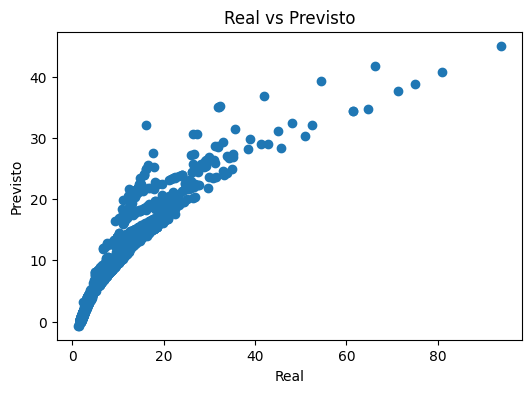

,real,previsto
0,4.14,4.251870
1,14.67,13.807971
2,4.91,5.548838
3,22.56,19.091936
4,2.30,1.275050
5,2.67,1.732760
6,2.62,1.807758
7,3.35,2.927968
8,5.16,5.413077
9,8.41,8.544245


In [13]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

modelo_reg = LinearRegression()
modelo_reg.fit(X_train_r, y_train_r)

y_pred_reg = modelo_reg.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_reg)
mse = mean_squared_error(y_test_r, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_reg)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

# gráfico
plt.figure(figsize=(6,4))
plt.scatter(y_test_r, y_pred_reg)
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.title("Real vs Previsto")
plt.show()

# comparação
pd.DataFrame({
    "real": y_test_r.values[:10],
    "previsto": y_pred_reg[:10]
})

## Análise dos resultados

No modelo de classificação, obtivemos uma boa acurácia, indicando que o modelo conseguiu identificar corretamente a maioria das vendas. Observamos também que o desempenho foi melhor para vendas baixas do que para vendas altas.

Já no modelo de regressão, as métricas apresentaram bons resultados, com um valor de R² elevado, mostrando que o modelo conseguiu explicar bem a variação dos dados.

Além disso, ao comparar os valores reais com os previstos, percebemos que eles ficaram próximos na maioria dos casos, indicando que o modelo teve um bom desempenho.

## Conclusão

Durante o desenvolvimento do projeto, conseguimos aplicar na prática as etapas do pipeline de Machine Learning.

Utilizamos um modelo de classificação para identificar se a venda é alta ou baixa, e um modelo de regressão para prever o valor total das vendas.

Os resultados foram satisfatórios, principalmente na regressão, onde os valores previstos ficaram próximos dos valores reais.